In [70]:
import gym
import talib
import numpy as np
import pandas as pd
import math
import torch
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import VecNormalize
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.utils import get_schedule_fn
from gym import spaces
import torch.nn as nn
import torch as th
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.ppo.policies import MlpPolicy
from stable_baselines3.common.vec_env import SubprocVecEnv
import torch
import os

sequence_len = 1
use_gpu = False
use_prev_action = True
use_comission = True
punish_negatives_extra = False
include_singular_rewards = False
use_fully_connected_after_stocks = False
use_common_dense_layers = False
compare_reward_to_mean = False
add_punishment_for_deviating_from_mean = False
add_punishment_for_deviating_from_mean_divider = 1000
use_multi_env = False
single_stock_reward = True
normalize_reward = False

if single_stock_reward:
    punish_negatives_extra = False
    use_prev_action = True
    normalize_reward = False

upper_cap = 1.02
lower_cap = 0.98
cash_interest = 0.04

if use_gpu:
    os.environ["PYTORCH_DISABLE_MODEL_LOADING_RAM_OPTIMIZATION"] = "1"
    torch.set_default_dtype(torch.float32)  # Ensure all tensors use float32
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
else:
    device = "cpu"

%run "../helpers/data_manipulator.py"

all_data = None
all_data_np = None

def calculate_reward(action, cash_balance, current_step, positions, last_prices, average_buy_prices, price_data, tickers, disable_comission=False):
    
    positions = positions.copy()
    last_prices = last_prices.copy()
    average_buy_prices = average_buy_prices.copy()
    
    penalty_strength = 0.03 / len(action)   # Tune this value to adjust punishment effect
    penalty = 0#-penalty_strength * np.sum(np.abs(action - ideal_value))

    today_value = cash_balance
    tomorrow_value_if_no_change = cash_balance + (cash_balance * 0.04 / 365)
    tomorrow_value_with_change = 0
    tomorrow_value_with_change_capped = 0
    reward = 0

    if use_comission and not disable_comission:
        comission = 0.002
    else:
        comission = 0.0

    for i, ticker in enumerate(my_stocks):
        today_stock_price = price_data[i, current_step]
        tomorrow_stock_price = price_data[i, current_step + 1]
        tomorrow_stock_price_capped = max(min(tomorrow_stock_price, today_stock_price * upper_cap), today_stock_price * lower_cap)
        today_value += today_stock_price * positions[i]
        tomorrow_value_if_no_change += tomorrow_stock_price_capped * positions[i]
        # print(f"current step: {self.current_step} ticker: {ticker}, today_stock_price: {today_stock_price}")

    # print(action)
    for i, act in enumerate(action):
        if i == len(action) - 1:
            ## MEANS THE CASH TO HOLD
            break
            
        ticker = tickers[i]
        
        today_stock_price = price_data[i, current_step]
        tomorrow_stock_price = price_data[i, current_step + 1]
        tomorrow_stock_price_capped = max(min(tomorrow_stock_price, today_stock_price * upper_cap), today_stock_price * lower_cap)
        
        today_stock_allocation = (today_stock_price * positions[i]) / today_value
        last_prices[i] = today_stock_price
        
        if act > today_stock_allocation and act > 0:
            desired_invest = act * today_value
            current_invest = today_stock_price * positions[i]
            diff = desired_invest - current_invest
            amount_to_buy = math.floor((diff / today_stock_price) * (1 - comission))
            if amount_to_buy > 0:
                positions[i] += amount_to_buy
                cash_balance -= (today_stock_price * amount_to_buy) * (1 + comission)
                if positions[i] > 0:
                    average_buy_prices[i] = ((average_buy_prices[i-1] * positions[i-1]) + (today_stock_price * amount_to_buy)) / positions[i]
                else:
                    average_buy_prices[i] = current_price
        elif act < today_stock_allocation:
            desired_invest = act * today_value
            current_invest = today_stock_price * positions[i]
            diff = current_invest - desired_invest
            amount_to_sell = math.ceil(diff / today_stock_price)
            if amount_to_sell > 0:
                positions[i] -= amount_to_sell
                cash_balance += (today_stock_price * amount_to_sell) * (1 - comission)
                
        tomorrow_value_with_change += tomorrow_stock_price * positions[i]
        tomorrow_value_with_change_capped += tomorrow_stock_price_capped * positions[i]

    
    cash_balance = cash_balance + cash_balance * cash_interest / 365
    tomorrow_value_with_change += cash_balance
    tomorrow_value_with_change_capped += cash_balance

    # print(f"tomorrow_value_with_change: {tomorrow_value_with_change}, tomorrow_value_if_no_change: {tomorrow_value_if_no_change}")
    # print(f"capped reward: {tomorrow_value_with_change_capped / tomorrow_value_if_no_change - 1.0} normal reward: {tomorrow_value_with_change / tomorrow_value_if_no_change - 1.0}")
    reward += tomorrow_value_with_change_capped / tomorrow_value_if_no_change - 1.0
    reward += penalty
    # if reward < -0.008:
    #     reward *= 4
    
    if punish_negatives_extra and reward < 0:
        reward *= 2
    # reward = min(0.035, reward)
    # reward = max(-0.03, reward)
    # reward = torch.log(torch.tensor(reward + 1))

    # 🔥 Compute the penalty: L2 norm of allocation change
    # action_change_penalty = np.linalg.norm(action - self.prev_action)

    # Compute final penalized reward
    # reward = reward - self.lambda_penalty * action_change_penalty

    # diff = 0.0
    # upper_threshold = max((1.0 / len(action)), 0.25)
    # lower_threshold = min((1.0 / len(action)), 0.05)
    # for i, act in enumerate(action):
    #     if act > upper_threshold:
    #         diff += act - upper_threshold
    #     elif act < lower_threshold:
    #         diff += lower_threshold - act
    # punishment = 0.01 * diff
    # reward -= punishment

    # print(f"XXXX: {self.cash_balance, self.current_step, self.positions, self.last_prices, self.average_buy_prices, self.tickers}")
    return reward, cash_balance, positions, last_prices, average_buy_prices

def calculate_daily_loss(actions, current_step, price_data, tickers):
    loss = 0
    # actions = actions * 0.2 - 0.1
    for i, ticker in enumerate(my_stocks):
        today_stock_price = price_data[i, current_step]
        tomorrow_stock_price = price_data[i, current_step + 1]
        diff = (tomorrow_stock_price / today_stock_price - 1.0)
        
        print(f"Loss for ticker: {ticker}: {actions[i] - diff} .. action: {actions[i]} .. diff: {diff} at current step: {current_step}")
        loss += abs(actions[i] - diff)
        
    # print(f"Loss for {loss} at current step: {current_step}")
    loss = loss / len(actions)
    loss = loss * loss / 100
    return loss

def normalize_reward_func(reward):
    return np.sign(reward) * (abs(reward) ** 0.4)
    # return reward + 1

class TradingEnv(gym.Env):
    def __init__(self, data, price_data, initial_balance=10000):
        super(TradingEnv, self).__init__()
        self.data = data
        self.price_data = price_data
        self.tickers = my_stocks
        self.lambda_penalty = 0.002
        self.initial_balance = initial_balance
        self.current_step = 0  # Start at 201 for history
        # self.max_steps = len(self.data[self.data["TICKER"] == my_stocks[0]]) - self.current_step
        self.max_steps = len(self.data) - self.current_step
        self.cash_balance = self.initial_balance
        self.positions = np.zeros(len(my_stocks))
        self.last_prices = np.zeros(len(my_stocks))
        self.total_reward = 1.0
        self.average_buy_prices = np.zeros(len(my_stocks))
       
        # For reward normalization
        self.reward_running_mean = 0.0
        self.reward_running_var = 1.0
        self.alpha = 0.01  # smoothing factor

        
        num_features = data.shape[3]#  - 2  # Exclude price column
        print(f"num_features: {num_features}")

        action_size = len(my_stocks)
        
        if not single_stock_reward:
            action_size += 1
        
        enlarged_action_size = action_size
        if include_singular_rewards:
            enlarged_action_size += len(my_stocks)
            low = np.array([0.0] * action_size + [-0.05] * len(my_stocks), dtype=np.float32)
            high = np.array([0.0] * action_size + [0.05] * len(my_stocks), dtype=np.float32)
        else:
            low = np.array([0.0] * action_size, dtype=np.float32)
            high = np.array([1.0] * action_size, dtype=np.float32)

        
        # Create the action space
        self.action_space = spaces.Box(low=low, high=high, dtype=np.float32)
        # Action space: 0 = Hold, 1 = Buy, 2 = Sell
        # self.action_space = spaces.Box(low=0.0, high=1.0, shape=(enlarged_action_size,), dtype=np.float32)
        
        print(f"self.action_space.shape: {self.action_space.shape}")
        self.prev_action = np.ones((action_size,), dtype=np.float32) / (len(my_stocks) + 1)
        
        # Observation space: Last sequence_len days of features
        # self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(len(my_stocks), sequence_len, num_features), dtype=np.float32)

        self.observation_space = spaces.Dict({
            "obs": spaces.Box(low=-np.inf, high=np.inf, shape=(len(my_stocks), sequence_len, num_features), dtype=np.float32),
            "prev_action": spaces.Box(low=0.0, high=1.0, shape=(len(my_stocks) + 1,), dtype=np.float32)
        })

    def seed(self, seed=None):
        """Set the seed for this environment's random number generator."""
        self.np_random, seed = gym.utils.seeding.np_random(seed)
        return [seed]
        
    def reset(self):
        
        action_size = len(my_stocks) + 1
        
        self.current_step = 0
        self.tickers = my_stocks
        self.cash_balance = self.initial_balance
        self.positions = np.zeros(len(my_stocks))
        self.last_prices = np.zeros(len(my_stocks))
        self.total_reward = 1.0
        self.average_buy_prices = np.zeros(len(my_stocks))
        self.prev_action = np.ones((action_size,), dtype=np.float32) / (len(my_stocks) + 1)
        
        return self._next_observation()

    def _next_observation(self):
        
        return {
            "obs": self.data[self.current_step],  # Current observation
            "prev_action": self.prev_action  # Previously taken action
        }
    
    def step(self, action):

        # print(f"action: {action}")
        if include_singular_rewards:
            singular_actions = action[-len(my_stocks):]
            action = action[:len(my_stocks)+1]

        if single_stock_reward:
            action = np.array([action[0], 1.0 - action[0]])

        # action = action * 0.2 + 0.05
        # print(f"actions: {action}")
        epsilon = 1e-8  # Small constant to prevent division by zero
        action /= (np.sum(action) + epsilon)
    
        ideal_value = 1 / len(action)  # 0.0909 for 11 actions
        ideal_actions = [ideal_value] * len(action)

        
        
        default_reward, _ , _ , _ , _ = calculate_reward(ideal_actions, self.cash_balance, self.current_step, self.positions.copy(), self.last_prices.copy(), self.average_buy_prices.copy(), self.price_data, self.tickers, disable_comission=True)
        my_reward, cash_balance, positions, last_prices, average_buy_prices = calculate_reward(action, self.cash_balance, self.current_step, self.positions, self.last_prices, self.average_buy_prices, self.price_data, self.tickers)
        
        self.cash_balance = cash_balance
        self.positions = positions
        self.last_prices = last_prices
        self.average_buy_prices = average_buy_prices

        # reward = 1000 * (torch.log(torch.tensor((my_reward - default_reward) + 1)) - loss)
        if compare_reward_to_mean:
            reward = my_reward - default_reward
            reward = 1000 * torch.log(torch.tensor(reward + 1))
        elif include_singular_rewards:
            loss = calculate_daily_loss(singular_actions, current_step, self.price_data, self.tickers)
            reward = my_reward - default_reward - loss
            reward *= 1000
        elif add_punishment_for_deviating_from_mean:
            diff_sum = np.sum(np.abs(action - ideal_actions))
            reward = my_reward - (diff_sum / add_punishment_for_deviating_from_mean_divider)
            reward = 1000 * torch.log(torch.tensor(reward + 1))
        else:
            reward = my_reward
            reward = 1000 * torch.log(torch.tensor(reward + 1))
            # print(f"reward: {reward}")


        # if single_stock_reward:
        #     today_stock_price = self.price_data[0, self.current_step]
        #     tomorrow_stock_price = self.price_data[0, self.current_step + 1]
        #     tomorrow_stock_price_capped = max(min(tomorrow_stock_price, today_stock_price * upper_cap), today_stock_price * lower_cap)
        #     reward = action[0] * ((tomorrow_stock_price_capped / today_stock_price) - 1.0)
        #     if punish_negatives_extra and reward < 0:
        #         reward *= 2
        #     if normalize_reward:
        #         reward = normalize_reward_func(reward)
        #         # reward = np.sign(reward) * np.sqrt(abs(0.5 * reward))
        #     else:
        #         reward = 1000 * torch.log(torch.tensor(reward + 1))



        
        self.current_step += 1
        # print(f"self.data.shape[0]: {self.data.shape[0]}")
        done = self.current_step >= self.data.shape[0] - 1
        
        # Store action for next timestep
        self.prev_action = action

        # print(f"reward: {reward}")
        
        obs = self._next_observation()
        self.total_reward *= reward
        return obs, reward, done, {}

all_data = pd.DataFrame()
all_data_val = pd.DataFrame()

for ticker in my_stocks:
    # GET RAW DATA FOR THE TICKER
    stock_file, earnings_file = fetch_finance_data_for_tickers(ticker, "10y", refresh=False, verbose=False, incl_earnings=True)
    data = pd.read_csv(stock_file)
    earnings = pd.read_csv(earnings_file)
    data = data.drop(data[data['Volume'] == 0].index)
    data.reset_index(drop=True, inplace=True)
    data = make_new_features_for(data, earnings=earnings, use_adj_close=True)
    data, data_val, _ = split_data(data,
                                train_cut_date = "2024-07-01",
                                validate_cut_date = "2025-03-01",
                                test_end_date = "2025-03-10",
                                train_start_date = "2016-07-01"
                               )
    normalized_data = normalize_data(data, ticker)
    normalized_data_val = normalize_data(data_val, ticker)
    normalized_data["Close"] = data["Adj Close"]
    normalized_data_val["Close"] = data_val["Adj Close"]
    data = normalized_data
    data_val = normalized_data_val
    all_data = pd.concat([all_data, data], ignore_index=True)
    all_data_val = pd.concat([all_data_val, data_val], ignore_index=True)


features_to_use = lstm_features_v2# + extra_dense_layers_features
    
print("Maximum values:\n", all_data[features_to_use].iloc[0:].max().to_dict())
print("\nMinimum values:\n", all_data[features_to_use].iloc[0:].min().to_dict())
    

obs = []
obs_val = []
for ticker in my_stocks:
    ticker_data = all_data[all_data["TICKER"] == ticker]
    ticker_data_val = all_data_val[all_data_val["TICKER"] == ticker]
    
    dat = ticker_data[features_to_use]
    dat = dat.values  

    dat_val = ticker_data_val[features_to_use]
    dat_val = dat_val.values
    
    # Create the sliding window array
    result = np.array([dat[i - (sequence_len-1):i+1] for i in range(sequence_len-1, len(dat))])
    result_val = np.array([dat_val[i - (sequence_len-1):i+1] for i in range(sequence_len-1, len(dat_val))])
    
    # Result shape: (100 - 20, 21, 3) → (80, 21, 3)
    print(result.shape)  # Should print (80, 21, 3)
    print(result_val.shape)  # Should print (80, 21, 3)

    obs.append(result)
    obs_val.append(result_val)

    

# print(obs.to_numpy())
obs = np.array(obs)
obs = obs.transpose(1, 0, 2, 3)
obs = obs.astype(np.float32)
print(obs.shape)

# print(obs.to_numpy())
obs_val = np.array(obs_val)
obs_val = obs_val.transpose(1, 0, 2, 3)
obs_val = obs_val.astype(np.float32)
print(obs_val.shape)




unique_tickers = all_data["TICKER"].unique()

# Convert to a 2D array where rows = tickers, cols = Close values
all_data_np = np.array([all_data[all_data["TICKER"] == ticker]["Close"].values for ticker in unique_tickers], dtype=object)
all_data_np_val = np.array([all_data_val[all_data_val["TICKER"] == ticker]["Close"].values for ticker in unique_tickers], dtype=object)

all_data_np = all_data_np[:, sequence_len-1:]
all_data_np_val = all_data_np_val[:, sequence_len-1:]


print(f"all_data_np.shape: {all_data_np.shape}")

def calculate_output_for_cnn(initial_len, cnn_depth=3):
    affect = math.floor((initial_len-1)/2)
    if (cnn_depth == 1): 
        return affect
    else:
        return calculate_output_for_cnn(affect, cnn_depth-1)

class SharedStockNetwork(BaseFeaturesExtractor):
    def __init__(self, observation_space: spaces.Dict, num_stocks, input_dim):

        total_end = 100
        
        obs_dim = observation_space.spaces["obs"].shape[0]
        action_dim = observation_space.spaces["prev_action"].shape[0]
        print(f"obs_dim: {obs_dim}, action_dim: {action_dim}, num_stocks: {num_stocks}")
        total_input_dim = obs_dim + action_dim  # Combined input

        features_dim = num_stocks #+ action_dim # Must match final layer output
        # self.daily_dense_output = 83
        self.daily_dense_output = 4
        cnn_end = 4

        stocks_output = num_stocks * cnn_end
        total_output = stocks_output
        
        if use_common_dense_layers:
            final_output = 128
        else:
            if use_fully_connected_after_stocks:
                final_output = total_output * 4
            else:
                final_output = total_output
            if use_prev_action:
                final_output += action_dim
        super(SharedStockNetwork, self).__init__(observation_space, 
                                                 final_output)
        # super(SharedStockNetwork, self).__init__(observation_space, total_end)

        self.shared_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim * sequence_len, 32),
            nn.ReLU(),
        )
        
        self.daily_stock_dense = nn.Sequential(
            nn.Dropout(p=0.18),
            nn.Linear(input_dim, 64),
            nn.LeakyReLU(),
            nn.Dropout(p=0.16),
            nn.Linear(64, 16),
            nn.LeakyReLU(),
            nn.Dropout(p=0.14),
            nn.Linear(16, 16),
            nn.LeakyReLU(),
            nn.Dropout(p=0.12),
            nn.Linear(16, 4),
            nn.LeakyReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(4, self.daily_dense_output),
            nn.Sigmoid(),
        )

        # Create a separate daily_stock_dense for each stock
        self.daily_stock_dense_list = nn.ModuleList([
            nn.Sequential(
                # nn.Dropout(p=0.10),
                # nn.BatchNorm1d(input_dim),
                nn.Linear(input_dim, 64),
                # nn.BatchNorm1d(64),
                nn.LeakyReLU(),
                # nn.Dropout(p=0.10),
                nn.Linear(64, 32),
                # nn.BatchNorm1d(32),
                # nn.LayerNorm(32),
                nn.LeakyReLU(),
                # nn.Linear(64, 32),
                # nn.BatchNorm1d(32),
                # nn.LeakyReLU(),
                # nn.Dropout(p=0.08),
                nn.Linear(32, 16),
                # nn.BatchNorm1d(16),
                # nn.LayerNorm(16),
                nn.LeakyReLU(),
                # nn.Dropout(p=0.08),
                # nn.Linear(16, 16),
                # nn.ReLU(),
                # nn.Dropout(p=0.08),
                # nn.Linear(8, 4),
                # nn.ReLU(),
                # nn.Dropout(p=0.1),
                nn.Linear(16, self.daily_dense_output),
                # nn.BatchNorm1d(self.daily_dense_output),
                nn.LeakyReLU(),
                # nn.Tanh(),
            ) for _ in range(num_stocks)  # Create a unique layer for each stock
        ])

        if sequence_len > 1:
            # 1D Convolution across stocks
            self.conv = nn.Sequential(
                # nn.BatchNorm1d(self.daily_dense_output),
                nn.Conv1d(
                    in_channels=input_dim,  # Convolution across stocks, not features
                    out_channels=8,  # Number of filters
                    kernel_size=2
                ),
                nn.BatchNorm1d(8),
                nn.LeakyReLU(),
                nn.Conv1d(
                    in_channels=8,  # Convolution across stocks, not features
                    out_channels=32,  # Number of filters
                    kernel_size=23,  # Consider 3 neighboring stocks
                ),
                nn.BatchNorm1d(32),
                nn.LeakyReLU(),
                # nn.Conv1d(
                #     in_channels=128,  # Convolution across stocks, not features
                #     out_channels=64,  # Number of filters
                #     kernel_size=3,  # Consider 3 neighboring stocks
                #     stride=2
                # ),
                # nn.BatchNorm1d(64),
                # nn.LeakyReLU(),
                nn.Flatten(),
                nn.Linear(32, cnn_end),
                nn.BatchNorm1d(cnn_end),
                nn.LeakyReLU(),
                # nn.Linear(256, 64),
                # nn.BatchNorm1d(64),
                # nn.LeakyReLU(),
                # nn.Linear(64, cnn_end),
                # nn.BatchNorm1d(cnn_end),
                # nn.LeakyReLU(),
                # nn.Sigmoid(),
                # nn.Linear(128, 32),
                # nn.ReLU(),
                # nn.Linear(128, cnn_end),
                # nn.BatchNorm1d(cnn_end),
                # nn.LeakyReLU()
                # nn.Sigmoid(),
            )
        # 1D Convolution across stocks
        self.stock_conv = nn.Sequential(
            nn.Conv1d(
                in_channels=cnn_end,  # Convolution across stocks, not features
                out_channels=1000,  # Number of filters
                kernel_size=10
            ),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(1000, total_end),
            nn.ReLU(),
        )

        self.fc_after_combined_cnn = nn.Sequential(
            nn.Linear(num_stocks * cnn_end , num_stocks * cnn_end * 2),
            nn.ReLU(),
            nn.Linear(num_stocks * cnn_end * 2 , num_stocks * cnn_end),
            nn.ReLU(),
        )
        self.prev_action_fc = nn.Sequential(
            nn.Linear(action_dim, action_dim),
            nn.ReLU()
        )
        
        self.fully_connected = nn.Sequential(
            nn.Linear(stocks_output, stocks_output * 4),
            nn.BatchNorm1d(stocks_output * 4),
            nn.LeakyReLU(),
            # nn.Linear(stocks_output * 4, stocks_output * 2),
            # nn.BatchNorm1d(stocks_output * 2),
            # nn.LeakyReLU(),
            # nn.Linear(stocks_output * 2, stocks_output),
            # nn.BatchNorm1d(stocks_output),
            # nn.LeakyReLU(),
            # nn.Linear(total_output * 2, total_output),
            # nn.ReLU()
        )

    
        self.common_layers = nn.Sequential(
            nn.Linear(total_output, total_output),
            nn.BatchNorm1d(total_output),
            nn.LeakyReLU(),
            nn.Linear(total_output, total_output),
            nn.BatchNorm1d(total_output),
            nn.LeakyReLU(),
            # nn.Linear(total_output, total_output),
            # # nn.BatchNorm1d(total_output),
            # nn.LeakyReLU(),
            nn.Linear(total_output, final_output),
            nn.BatchNorm1d(total_output),
            nn.LeakyReLU(),
            # nn.Linear(32, 32),
            # # nn.BatchNorm1d(total_output),
            # nn.LeakyReLU(),
            # nn.Linear(32, 32),
            # # nn.BatchNorm1d(total_output),
            # nn.LeakyReLU(),
            # nn.Linear(32, final_output),
            # # nn.BatchNorm1d(total_output),
            # nn.LeakyReLU(),
            # nn.Linear(stocks_output * 4, stocks_output * 2),
            # nn.BatchNorm1d(stocks_output * 2),
            # nn.LeakyReLU(),
            # nn.Linear(stocks_output * 2, stocks_output),
            # nn.BatchNorm1d(stocks_output),
            # nn.LeakyReLU(),
            # nn.Linear(total_output * 2, total_output),
            # nn.ReLU()
        )

        self.flatten = nn.Sequential(
            nn.Flatten()
        )
    
    def forward(self, observations):
        obs = observations["obs"]
        prev_action = observations["prev_action"]

        # print(f"x.shape: {x.shape}")
        batch_size, num_stocks, sequence_len, features_len = obs.shape
        # print(f"batch_size, num_stocks, sequence_len, features_len: {batch_size, num_stocks, sequence_len, features_len}")
        
        # x = x.permute(0, 2, 1)  # Move stock dimension to be iterated
        # shared_outputs = [self.shared_layers(x[:, i, :, :]) for i in range(num_stocks)]
        # combined = torch.cat(shared_outputs, dim=-1)
        # final_layer = self.final_layer(combined)
        # flatten = self.flatten(final_layer)
        # return self.fully_connected(flatten)

        # # Apply a different `daily_stock_dense` layer for each stock
        # daily_results = []
        # for i in range(num_stocks):
        #     daily = obs[:, i, :, :].view(-1, features_len)  # Extract data for stock i
        #     daily_result = self.daily_stock_dense_list[i](daily)  # Use specific layer for stock i
        #     daily_results.append(daily_result)

        # # Stack results back together
        # daily_result = torch.stack(daily_results, dim=1).view(batch_size, num_stocks, sequence_len, self.daily_dense_output)

        
        # # Stack the results to match the original stock dimension
        if sequence_len > 1:
            output = obs
        else:
            daily_results = []
            for i in range(num_stocks):
                # Extract data for stock i across all batches and sequences
                daily = obs[:, i, :, :].reshape(-1, features_len)  # Ensures correct reshaping
                
                # Apply the corresponding dense layer for this stock
                daily_result = self.daily_stock_dense_list[i](daily)  
            
                # Reshape back to match batch and sequence dimensions
                daily_results.append(daily_result.view(batch_size, sequence_len, -1))
            
            output = torch.stack(daily_results, dim=1)  # Shape: (batch_size, num_stocks, sequence_len, dense_output_size)

        
        # print(f"obs.shape: {obs.shape}")
        # daily = obs.view(-1, features_len)
        # daily_result = self.daily_stock_dense(daily)
        # print(f"daily_result.shape: {daily_result.shape}")
        
        # Step 3: Reshape back to (batch_size, stocks, sequence)
        # daily_result = daily_result.view(batch_size, num_stocks, sequence_len, self.daily_dense_output)
        # print(f"daily_result.shape2: {daily_result.shape}")

        obs_shaped = output.permute(0, 1, 3, 2)
        if sequence_len > 1:
            stock_outputs = torch.stack([self.conv(obs_shaped[:, i, :, :]) for i in range(num_stocks)], dim=1)
        else:
            stock_outputs = torch.stack([self.flatten(obs_shaped[:, i, :, :]) for i in range(num_stocks)], dim=1)
        
        # stock_outputs = stock_outputs.permute(0, 2, 1)
        # double_cnn_outputs = self.stock_conv(stock_outputs)
        
        # print(f"stock_outputs.shape: {stock_outputs.shape}")
        # all_stocks_output = self.final_layer(stock_outputs)
        
        # print(f"stock_outputs.shape: {stock_outputs.shape}")
        stock_outputs = stock_outputs.flatten(start_dim=1)
        double_cnn_outputs = stock_outputs #self.fc_after_combined_cnn(stock_outputs)
        # print(f"stock_outputs.shape: {stock_outputs.shape}")
        
        ## POLICY
        # stock_outputs = torch.stack([self.shared_layers(obs[:, i, :, :]) for i in range(num_stocks)], dim=1)
        
        
        # prev_actions_outputs = self.prev_action_fc(prev_action)
        # combined = torch.cat([double_cnn_outputs, prev_action], dim=1)
        # policy_net = self.fully_connected(combined)

        if use_fully_connected_after_stocks:
            policy_net = self.fully_connected(double_cnn_outputs)
        else:
            policy_net = double_cnn_outputs

        if use_prev_action:
            policy_net = torch.cat([policy_net, prev_action], dim=1)

        if use_common_dense_layers:
            policy_net = self.common_layers(policy_net)
            
        
        ## VALUE
        # stock_outputs = torch.stack([self.shared_layers(obs[:, i, :, :]) for i in range(num_stocks)], dim=1)
        # value_net = self.final_layer(stock_outputs)
        
        # combined = torch.cat([all_stocks_output, prev_action], dim=1)
        
        # print(f"ASDASFD:{shared_outputs.shape}")
        # shared_outputs = shared_outputs.permute(0, 2, 1)  # (batch, features_dim, stocks)
        # conv_outputs = self.conv(shared_outputs)
        # x = x.view(batch_size * num_stocks, sequence_len, features_len)  # Flatten stock dimension
        # shared_outputs = self.shared_layers(x)  # Process all stocks in parallel
        # shared_outputs = shared_outputs.view(batch_size, num_stocks, -1)  # Reshape back
        # combined = shared_outputs.flatten(start_dim=1)  # Flatten stock outputs

        
        return policy_net
        # return all_stocks_output
        
        

from stable_baselines3.common.policies import MultiInputActorCriticPolicy
# import torch.nn as nn
# import torch.nn.functional as F
# from stable_baselines3.common.distributions import Distribution
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# 
# class DirichletDistribution(Distribution):
#     def __init__(self, action_dim):
#         super(DirichletDistribution, self).__init__()
#         self.action_dim = action_dim
#         # Learnable exploration parameter
#         self.exploration_param = nn.Parameter(torch.tensor(1.0, requires_grad=True))
        
#     def proba_distribution_net(self, latent_dim):
#         # Just a linear layer to produce concentration parameters
#         concentration_params = nn.Linear(latent_dim, self.action_dim)
#         return concentration_params
        
#     def proba_distribution(self, concentration_logits):
#         # Dynamic concentration with exploration scaling
#         scaling = torch.sigmoid(self.exploration_param)
        
#         # Apply dynamic scaling and add noise
#         self._concentration = (F.softplus(concentration_logits * scaling) * 0.5) + 0.5
        
#         # Ensure minimum concentration
#         self._concentration = torch.clamp(self._concentration, min=0.1)
        
#         # Add small random noise to encourage exploration
#         noise = torch.randn_like(self._concentration) * 0.1 * scaling
#         self._concentration += noise
        
#         # Create the Dirichlet distribution
#         self._dirichlet = torch.distributions.Dirichlet(self._concentration)
#         return self
    
#     def entropy(self):
#         # Dynamically scaled entropy with exploration parameter
#         base_entropy = self._dirichlet.entropy()
#         exploration_scale = torch.abs(self.exploration_param)
        
#         # Adaptive entropy calculation with sigmoid scaling
#         adaptive_entropy = base_entropy * torch.sigmoid(exploration_scale)
        
#         return adaptive_entropy.unsqueeze(-1)
    
#     def actions_from_params(self, concentration_logits, deterministic=False):
#         self.proba_distribution(concentration_logits)
#         if deterministic:
#             actions = self.mode()
#         else:
#             actions = self.sample()
#         log_prob = self.log_prob(actions)
#         return actions, log_prob
    
#     def log_prob_from_params(self, concentration_logits, actions=None, deterministic=False):
#         self.proba_distribution(concentration_logits)
        
#         if actions is None:
#             if deterministic:
#                 actions = self.mode()
#             else:
#                 actions = self.sample()
        
#         log_prob = self.log_prob(actions)
#         return actions, log_prob
        
#     def log_prob(self, actions):
#         return self._dirichlet.log_prob(actions).unsqueeze(-1)
        
#     def sample(self):
#         return self._dirichlet.sample()
        
#     def mode(self):
#         return self._concentration / torch.sum(self._concentration, dim=1, keepdim=True)
        

# class DirichletMultiInputPolicy(MultiInputActorCriticPolicy):
#     def __init__(self, *args, **kwargs):
#         super().__init__(*args, **kwargs)
#         action_dim = self.action_space.shape[0]
#         self.action_dist = DirichletDistribution(action_dim)
    
#     def _get_action_dist_from_latent(self, latent_pi):
#         # Get the concentration parameters from the action net
#         concentration_logits = self.action_net(latent_pi)
        
#         # Explicitly print or log the exploration parameter
#         print(f"Exploration Parameter: {self.action_dist.exploration_param.data}")
        
#         # Use our Dirichlet distribution
#         return self.action_dist.proba_distribution(concentration_logits)
    
#     def evaluate_actions(self, obs, actions):
#         # Override to ensure our custom entropy is used
#         latent_pi, latent_vf, _ = self.mlp_extractor(self.extract_features(obs))
        
#         # Get distribution from latent
#         distribution = self._get_action_dist_from_latent(latent_pi)
        
#         # Calculate log probabilities
#         log_prob = distribution.log_prob(actions)
        
#         # Use our custom entropy calculation
#         entropy = distribution.entropy()
        
#         # Value function
#         values = self.value_net(latent_vf)
        
#         return values, log_prob, entropy

policy_kwargs = dict(
    features_extractor_class=SharedStockNetwork
    ,features_extractor_kwargs={"num_stocks": len(my_stocks), "input_dim": len(features_to_use)}
    ,net_arch=dict(pi=[4], vf=[4])  # More layers for value network
    # ,activation_fn=nn.Sigmoid  # ✅ Pass the class, NOT an instance
    # ,log_std_init=0.0
)

import torch
import torch.nn.functional as F
from stable_baselines3 import PPO

class PPOWithMAE(PPO):
    def _update_policy(self, loss, approx_kl):
        """Modify loss function to use MAE for value function."""
        # Extract components from PPO loss
        policy_loss, value_loss, entropy_loss = loss

        # Convert MSE to MAE for value function
        value_loss = F.l1_loss(self.rollout_buffer.returns, self.rollout_buffer.values)
        # value_loss = torch.log(torch.cosh(self.rollout_buffer.returns - self.rollout_buffer.values)).mean()


        # Final loss combination (following PPO structure)
        total_loss = policy_loss + self.ent_coef * entropy_loss + self.vf_coef * value_loss

        return super()._update_policy(total_loss, approx_kl)


from stable_baselines3.common.callbacks import BaseCallback
import torch

class StopTrainingCallback(BaseCallback):
    def __init__(self, threshold_entropy=0.0, target_kl=0.01, lr_reduction_factor=0.4, min_lr=1e-6, 
                 threshold_policy_grad=-0.1, threshold_explained_var=0.9, verbose=1):
        super().__init__(verbose)
        self.threshold_entropy = threshold_entropy
        self.target_kl = target_kl
        self.lr_reduction_factor = lr_reduction_factor  # Added this
        self.min_lr = min_lr  # Added this
        self.threshold_policy_grad = threshold_policy_grad
        self.threshold_explained_var = threshold_explained_var
        self.approx_kl_counter = 0
        self.rewards = []


        # if len(self.model.logger.name_to_value) > 0 and "train/approx_kl" in self.model.logger.name_to_value:
        #     approx_kl = self.model.logger.name_to_value["train/approx_kl"]
        #     print(f"approx_kl: {approx_kl}")
            
        #     # If KL is too high, reduce learning rate
        #     if approx_kl > 2 * self.target_kl:
        #         old_lr = self.model.learning_rate
        #         new_lr = max(old_lr * self.lr_reduction_factor, self.min_lr)

        #         self.model.policy.optimizer = torch.optim.Adam(self.model.policy.parameters(), lr=new_lr)
        #         self.model.learning_rate = new_lr
        #         for param_group in self.model.policy.optimizer.param_groups:
        #             param_group['lr'] = new_lr
                
        #         print(f"Updated LR: {new_lr}")
                
        #         if self.verbose > 0:
        #             print(f"KL divergence too high ({approx_kl:.5f} > {2 * self.target_kl:.5f}), "
        #                   f"reducing learning rate from {old_lr:.6f} to {new_lr:.6f}")
    
    def _on_step(self) -> bool:
        self.rewards.append(self.locals["rewards"][0]) 
        """ This function is called at each training step. """
        # approx_kl is stored in the logger during training
        # Access the PPO model's losses from its logger
        try:
            entropy_loss = self.model.logger.name_to_value["train/entropy_loss"]
            policy_gradient_loss = self.model.logger.name_to_value["train/policy_gradient_loss"]
            approx_kl = self.model.logger.name_to_value["train/approx_kl"]
            explained_variance = self.model.logger.name_to_value["train/explained_variance"]
            std = self.model.logger.name_to_value["train/std"]
        except KeyError:
            if self.verbose:
                print("[WARNING] Could not retrieve some metrics, skipping check.")
            return True  # Continue training if values are not found
        
        # 🚨 Stopping conditions
        # if entropy_loss > self.threshold_entropy:
        #     print(f"[STOP] Entropy loss is above {self.threshold_entropy}! Possible bug.")
        #     return False  # Stop training
        if self.model._n_updates > 200 and approx_kl > 1.0:
            self.approx_kl_counter += 1
            if self.approx_kl_counter > 10:
                print(f"[STOP] Approx KL ({approx_kl:.2f}) is too high, stopping training.")
                return False  # Stop training
        else:
            self.approx_kl_counter = 0
                
        # if abs(policy_gradient_loss) > self.threshold_policy_grad:
        #     print(f"[STOP] Policy gradient loss is very small ({policy_gradient_loss:.5f}), stopping training.")
        #     return False  # Stop training
        if explained_variance > self.threshold_explained_var and std < 0.5:
            print(f"[STOP] Explained variance ({explained_variance:.2f}) is too high, stopping training.")
            return False  # Stop training
        
        return True  # Continue training

    def _on_rollout_end(self):
        """Called at the end of each PPO update (after batch is collected)."""
        avg_reward = sum(self.rewards) / len(self.rewards) if self.rewards else 0
        # print(f"PPO Iteration self.rewards: {self.rewards}")
        print(f"PPO Iteration Average Reward: {avg_reward:.4f}")
        self.rewards = []  # Reset for next iteration


def make_env(obs_data, price_data, rank, seed=0):
    def _init():
        env = TradingEnv(obs_data, price_data)
        env.seed(seed + rank)
        return env
    return _init

if use_multi_env:
    # Number of parallel environments
    num_envs = 4  # Adjust based on CPU cores available
    
    # Create a list of environment factory functions
    env_fns = [make_env(obs, all_data_np, i) for i in range(num_envs)]
    
    # Create the vectorized environment
    env = SubprocVecEnv(env_fns, start_method='spawn')
else:
    num_envs = 1
    # Setup Environment
    env = DummyVecEnv([lambda: TradingEnv(obs, all_data_np)])
    
    env.tickers = my_stocks


model = PPOWithMAE(
    'MultiInputPolicy',
    env, 
    verbose=1, 
    gamma=0.9,
    batch_size=256,
    n_steps=obs.shape[0] // num_envs, # Adjust steps per environment Why is this needed?
    learning_rate=0.0004,
    max_grad_norm=0.2,
    ent_coef=0.001,
    clip_range=0.2,
    vf_coef=0.9,
    gae_lambda=0.9,
    n_epochs=8,
    # use_sde=True,
    # target_kl=0.003,
    seed=42,
    policy_kwargs=policy_kwargs,
    device=device  # Use GPU if available
)

model.learning_rate = 0.0004
model._setup_lr_schedule()

# # Change gamma value
# model.gamma = 0.9  # Set your desired gamma value
# # For the change to take effect
# model._setup_model()


# Access the current optimizer
current_optimizer = model.policy.optimizer

# new_optimizer = torch.optim.Adam(model.policy.parameters(), lr=0.001, weight_decay=0.000005)
# model.policy.optimizer = new_optimizer

if use_gpu:
    model.policy.to(torch.float32)  # Convert policy to float32

stop_callback = StopTrainingCallback()
model.learn(total_timesteps=3000000, callback=stop_callback)




# Setup Environment
test_env = DummyVecEnv([lambda: TradingEnv(obs, all_data_np)])

test_env.tickers = my_stocks
# Test Model
done = False
obs_step = test_env.reset()
# last_known_explianed_variance = None    
# cons_counter = 0

while not done:
    action, _states = model.predict(obs_step, deterministic=True)
    obs_step, reward, done, _ = env.step(action)
    print(f"Step: {env.envs[0].current_step}, Action: {action}, Reward: {reward}, Last Price: {env.envs[0].last_prices} Position: {env.envs[0].positions} Total Balance: {env.envs[0].cash_balance + np.sum(env.envs[0].positions * env.envs[0].last_prices)} Total Reward: {env.envs[0].total_reward}, Cash Balance: {env.envs[0].cash_balance}, Position Balance: {np.sum(env.envs[0].positions * env.envs[0].last_prices)}")

    # explained_variance = model.logger.name_to_value.get("train/explained_variance", None)
    # entropy_loss = model.logger.name_to_value.get("train/entropy_loss", None)

    # if entropy_loss > 0:
    #     print(f"Early stopping triggered! Entropy loss went above 0 {entropy_loss}.")
    
    # if explained_variance is not None:
    #     if last_known_explianed_variance is not None:
    #         if explianed_variance < last_known_explianed_variance:
    #             cons_counter += 1
    #             last_known_explianed_variance = explianed_variance
    #         else:
    #             cons_counter = 0
    #             last_known_explianed_variance = None
            
    # if last_known_explianed_variance is None and explained_variance > 0.9:
    #     last_known_explianed_variance = explained_variance

    # if cons_counter == 5:
    #     print(f"Early stopping triggered! Explained variance reached {explained_variance}.")
    #     break  # Stop the loop

fetch_finance_data_for_tickers: just returning file name: MSFT for interval: 10y
DOING EARNINGS
fixed_mean: -9.867214350423036e-08, fixed_stddev: 0.011260524843983358
train_data:            Date        Open        High         Low       Close      Volume  \
319  2016-07-05   50.830002   51.279999   50.740002   45.685921  24806400.0   
320  2016-07-06   50.779999   51.540001   50.389999   45.873425  28167500.0   
321  2016-07-07   51.419998   51.610001   51.070000   45.873425  19585200.0   
322  2016-07-08   51.730000   52.360001   51.549999   46.694820  28391000.0   
323  2016-07-11   52.500000   52.830002   52.470001   46.953743  22269200.0   
...         ...         ...         ...         ...         ...         ...   
2325 2024-06-25  448.250000  451.420013  446.750000  448.340454  16747500.0   
2326 2024-06-26  449.000000  453.600006  448.190002  449.543457  16507000.0   
2327 2024-06-27  452.179993  456.170013  451.769989  450.229462  14806300.0   
2328 2024-06-28  453.070007  45

/opt/homebrew/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names,

PPO Iteration Average Reward: -0.5583
-----------------------------
| time/              |      |
|    fps             | 6281 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 2011 |
-----------------------------
PPO Iteration Average Reward: -0.8579
------------------------------------------
| time/                   |              |
|    fps                  | 5836         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 4022         |
| train/                  |              |
|    approx_kl            | 0.0002687131 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.42        |
|    explained_variance   | -0.00355     |
|    learning_rate        | 0.0004       |
|    loss                 | 126          |
|    n_updates            | 8            |
|    policy_gradient_loss | -0.000531    |
|    std                  

KeyboardInterrupt: 

In [ ]:
### EXTRA LEARNING:

model.learning_rate = 0.00004
model._setup_lr_schedule()

stop_callback = StopTrainingCallback()
model.learn(total_timesteps=4000000, callback=stop_callback)

In [61]:
### TRAINING DATA. FIXED PORTFOLIO

env = DummyVecEnv([lambda: TradingEnv(obs, all_data_np)])
env.tickers = my_stocks

# Test Model
done = False
obs_row = env.reset()
# last_known_explianed_variance = None    
# cons_counter = 0
action_len = len(my_stocks)
if not single_stock_reward:
    action_len += 1
    

while not done:
    action = np.ones((action_len), dtype=np.float32) / (action_len)
    action = np.array([action])
    obs_row, reward, done, _ = env.step(action)
    print(f"Step: {env.envs[0].current_step}, Action: {action}, Reward: {reward}, Last Price: {env.envs[0].last_prices} Position: {env.envs[0].positions} Total Balance: {env.envs[0].cash_balance + np.sum(env.envs[0].positions * env.envs[0].last_prices)} Total Reward: {env.envs[0].total_reward}, Cash Balance: {env.envs[0].cash_balance}, Position Balance: {np.sum(env.envs[0].positions * env.envs[0].last_prices)}")


# total_pct = 0
# for i, ticker in enumerate(my_stocks):
#     pct = (all_data_np[i, -1] - all_data_np[i, 0]) / all_data_np[i, 0]
#     total_pct +=pct
#     print(f"percentage for ticker: {ticker}: {(all_data_np[i, -1] - all_data_np[i, 0]) / all_data_np[i, 0]}")
# total_pct /= len(my_stocks) + 1
# print(f"percentage if kept equal allocation all the time: {total_pct}")

num_features: 28
self.action_space.shape: (1,)
Step: 1, Action: [[1.]], Reward: [1.9841259], Last Price: [45.68592072] Position: [218.] Total Balance: 9980.083190647307 Total Reward: 1.9841258495548155, Cash Balance: 20.552474704924066, Position Balance: 9959.530715942383
Step: 2, Action: [[1.]], Reward: [0.], Last Price: [45.87342453] Position: [218.] Total Balance: 10020.961274577307 Total Reward: 0.0, Cash Balance: 20.554727030919125, Position Balance: 10000.406547546387
Step: 3, Action: [[1.]], Reward: [0.], Last Price: [45.87342453] Position: [218.] Total Balance: 10020.963527150132 Total Reward: 0.0, Cash Balance: 20.55697960374443, Position Balance: 10000.406547546387
Step: 4, Action: [[1.]], Reward: [0.], Last Price: [46.6948204] Position: [218.] Total Balance: 10200.030080506924 Total Reward: 0.0, Cash Balance: 20.559232423427034, Position Balance: 10179.470848083496
Step: 5, Action: [[1.]], Reward: [0.], Last Price: [46.95374298] Position: [218.] Total Balance: 10256.47745533

num_features: 28
self.action_space.shape: (1,)
Step: 1, Action: [[0.]], Reward: [0.], Last Price: [45.68592072] Position: [0.] Total Balance: 10001.09589041096 Total Reward: 0.0, Cash Balance: 10001.09589041096, Position Balance: 0.0
Step: 2, Action: [[0.]], Reward: [0.], Last Price: [45.87342453] Position: [0.] Total Balance: 10002.191900919497 Total Reward: 0.0, Cash Balance: 10002.191900919497, Position Balance: 0.0
Step: 3, Action: [[0.]], Reward: [0.], Last Price: [45.87342453] Position: [0.] Total Balance: 10003.288031538776 Total Reward: 0.0, Cash Balance: 10003.288031538776, Position Balance: 0.0
Step: 4, Action: [[0.]], Reward: [0.], Last Price: [46.6948204] Position: [0.] Total Balance: 10004.384282281959 Total Reward: 0.0, Cash Balance: 10004.384282281959, Position Balance: 0.0
Step: 5, Action: [[0.]], Reward: [0.], Last Price: [46.95374298] Position: [0.] Total Balance: 10005.480653162209 Total Reward: 0.0, Cash Balance: 10005.480653162209, Position Balance: 0.0
Step: 6, Ac

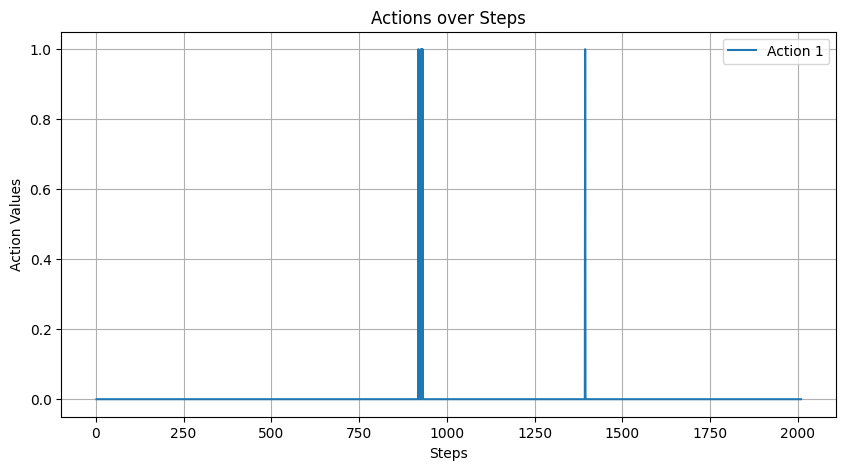

/var/folders/1n/8vt634f15059yz_p3_whxnk80000gn/T/ipykernel_2792/3710083534.py:47: RuntimeWarning: invalid value encountered in divide
  actions_array[1:-1] = actions_array[1:-1] / actions_array[1:-1].sum(axis=1, keepdims=True)


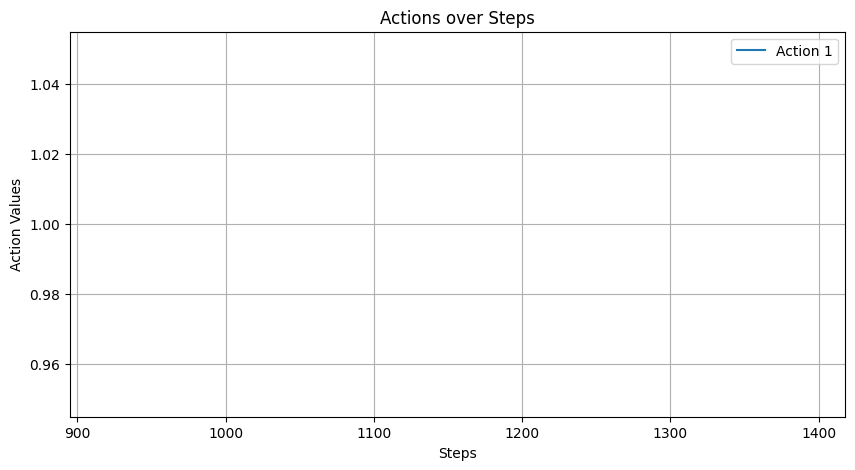

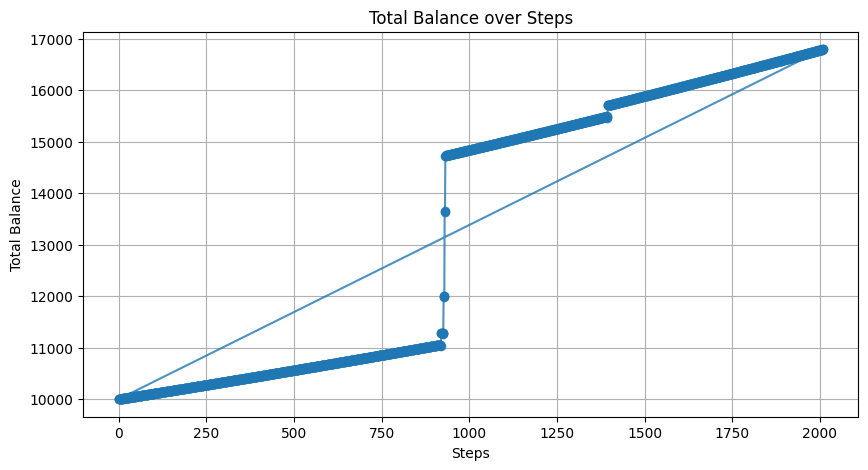

In [65]:

import matplotlib.pyplot as plt
# Create environment for new data
env = DummyVecEnv([lambda: TradingEnv(obs, all_data_np)])

# Test Model
done = False
obs_val_pre = env.reset()
env.current_step = 0

# Assuming you have collected these values during your loop
steps = []  # List to store step numbers
actions_list = []  # List to store action values
total_balances = []  # List to store total balances
# last_known_explianed_variance = None    
# cons_counter = 0

while not done:
    action, _states = model.predict(obs_val_pre, deterministic=True)
    obs_val_pre, reward, done, _ = env.step(action)

    steps.append(env.envs[0].current_step)
    actions_list.append(action.flatten())  # Flatten to make it 1D
    total_balances.append(env.envs[0].cash_balance + np.sum(env.envs[0].positions[0] * env.envs[0].last_prices[0]))

    print(f"Step: {env.envs[0].current_step}, Action: {action}, Reward: {reward}, Last Price: {env.envs[0].last_prices} Position: {env.envs[0].positions} Total Balance: {env.envs[0].cash_balance + np.sum(env.envs[0].positions * env.envs[0].last_prices)} Total Reward: {env.envs[0].total_reward}, Cash Balance: {env.envs[0].cash_balance}, Position Balance: {np.sum(env.envs[0].positions * env.envs[0].last_prices)}")

# Convert actions to a NumPy array for easier plotting
actions_array = np.array(actions_list)

# Plot Actions over Steps
plt.figure(figsize=(10, 5))
action_space = actions_array.shape[1]
if include_singular_rewards:
    action_space -= len(my_stocks)
for i in range(action_space):
    plt.plot(steps[1:-1], actions_array[1:-1, i], label=f'Action {i+1}')

plt.xlabel('Steps')
plt.ylabel('Action Values')
plt.title('Actions over Steps')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
actions_array = actions_array[:, 0:action_space]
actions_array[1:-1] = actions_array[1:-1] / actions_array[1:-1].sum(axis=1, keepdims=True)
for i in range(action_space):
    plt.plot(steps[1:-1], actions_array[1:-1, i], label=f'Action {i+1}')

plt.xlabel('Steps')
plt.ylabel('Action Values')
plt.title('Actions over Steps')
plt.legend()
plt.grid(True)
plt.show()

# Plot Total Balance over Steps
plt.figure(figsize=(10, 5))
plt.plot(steps, total_balances, marker='o', linestyle='-', alpha=0.8)
plt.xlabel('Steps')
plt.ylabel('Total Balance')
plt.title('Total Balance over Steps')
plt.grid(True)
plt.show()

In [ ]:
## VALIDATION DATA
## VALIDATION DATA
## VALIDATION DATA
## VALIDATION DATA
## VALIDATION DATA
## VALIDATION DATA

In [ ]:
epsilon = 1e-8  # Small constant to prevent division by zero
total_pct = 0
for i, ticker in enumerate(my_stocks):
    pct = (all_data_np_val[i, -1] - all_data_np_val[i, 0]) / all_data_np_val[i, 0]
    total_pct +=pct
    print(f"percentage for ticker: {ticker}: {(all_data_np_val[i, -1] - all_data_np_val[i, 0]) / all_data_np_val[i, 0]}")
total_pct /= len(my_stocks)
print(f"percentage if kept equal allocation all the time: {total_pct}")

In [4]:
env = DummyVecEnv([lambda: TradingEnv(obs_val, all_data_np_val)])
env.tickers = my_stocks

# Test Model
done = False
obs_row = env.reset()
# last_known_explianed_variance = None    
# cons_counter = 0

while not done:
    action = np.ones(action_len), dtype=np.float32) / (len(my_stocks) + 1)
    action = np.array([action])
    obs_row, reward, done, _ = env.step(action)
    print(f"Step: {env.envs[0].current_step}, Action: {action}, Reward: {reward}, Last Price: {env.envs[0].last_prices} Position: {env.envs[0].positions} Total Balance: {env.envs[0].cash_balance + np.sum(env.envs[0].positions * env.envs[0].last_prices)} Total Reward: {env.envs[0].total_reward}, Cash Balance: {env.envs[0].cash_balance}, Position Balance: {np.sum(env.envs[0].positions * env.envs[0].last_prices)}")


SyntaxError: unmatched ')' (1184375564.py, line 11)

num_features: 28
self.action_space.shape: (1,)
Step: 1, Action: [[1.]], Reward: [0.10102858], Last Price: [456.62225342] Position: [21.] Total Balance: 9980.86479736122 Total Reward: 0.10102858293830241, Cash Balance: 391.79747558387925, Position Balance: 9589.067321777342
Step: 2, Action: [[1.]], Reward: [0.1850777], Last Price: [458.1036377] Position: [21.] Total Balance: 10012.016803895094 Total Reward: 0.0186981369328193, Cash Balance: 391.84041229353227, Position Balance: 9620.176391601562
Step: 3, Action: [[0.]], Reward: [0.], Last Price: [464.8543396] Position: [0.] Total Balance: 10135.368265201501 Total Reward: 0.0, Cash Balance: 10135.368265201501, Position Balance: 0.0
Step: 4, Action: [[0.]], Reward: [0.], Last Price: [463.54199219] Position: [0.] Total Balance: 10136.47899049084 Total Reward: 0.0, Cash Balance: 10136.47899049084, Position Balance: 0.0
Step: 5, Action: [[1.]], Reward: [0.1843995], Last Price: [456.88076782] Position: [22.] Total Balance: 10116.383359922507 

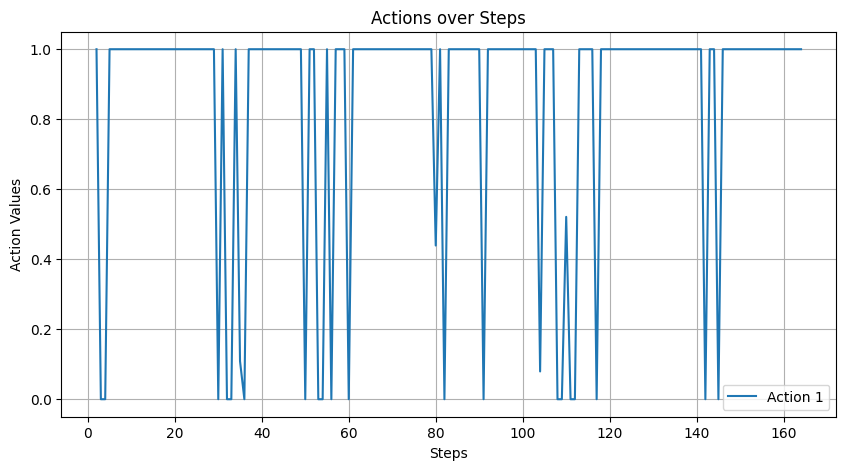

/var/folders/1n/8vt634f15059yz_p3_whxnk80000gn/T/ipykernel_2792/3721110829.py:47: RuntimeWarning: invalid value encountered in divide
  actions_array[1:-1] = actions_array[1:-1] / actions_array[1:-1].sum(axis=1, keepdims=True)


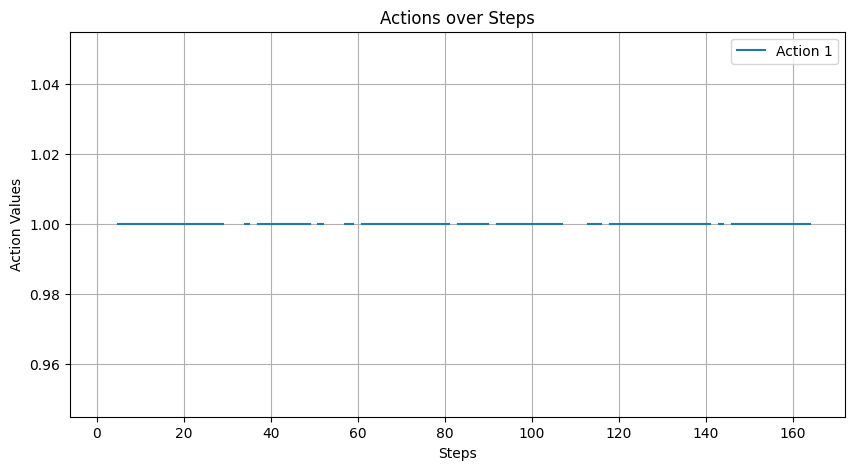

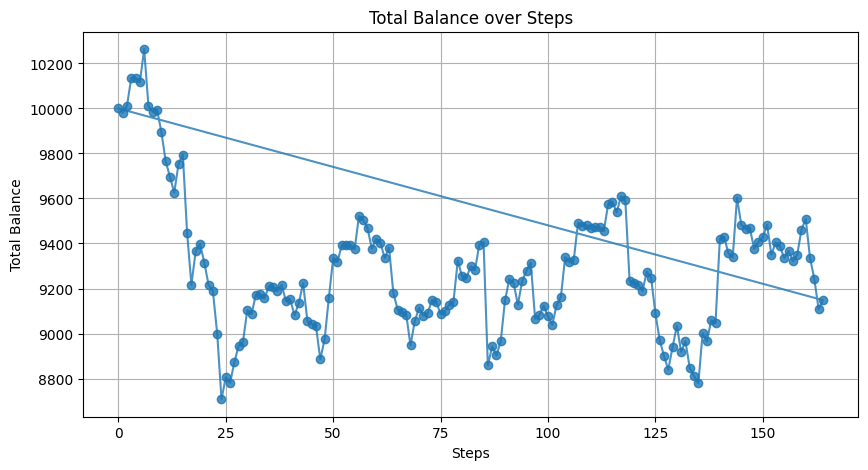

In [52]:

import matplotlib.pyplot as plt
# Create environment for new data
env = DummyVecEnv([lambda: TradingEnv(obs_val, all_data_np_val)])

# Test Model
done = False
obs_val_pre = env.reset()
env.current_step = 0

# Assuming you have collected these values during your loop
steps = []  # List to store step numbers
actions_list = []  # List to store action values
total_balances = []  # List to store total balances
# last_known_explianed_variance = None    
# cons_counter = 0

while not done:
    action, _states = model.predict(obs_val_pre, deterministic=True)
    obs_val_pre, reward, done, _ = env.step(action)

    steps.append(env.envs[0].current_step)
    actions_list.append(action.flatten())  # Flatten to make it 1D
    total_balances.append(env.envs[0].cash_balance + np.sum(env.envs[0].positions * env.envs[0].last_prices))

    print(f"Step: {env.envs[0].current_step}, Action: {action}, Reward: {reward}, Last Price: {env.envs[0].last_prices} Position: {env.envs[0].positions} Total Balance: {env.envs[0].cash_balance + np.sum(env.envs[0].positions * env.envs[0].last_prices)} Total Reward: {env.envs[0].total_reward}, Cash Balance: {env.envs[0].cash_balance}, Position Balance: {np.sum(env.envs[0].positions * env.envs[0].last_prices)}")

# Convert actions to a NumPy array for easier plotting
actions_array = np.array(actions_list)

# Plot Actions over Steps
plt.figure(figsize=(10, 5))
action_space = actions_array.shape[1]
if include_singular_rewards:
    action_space -= len(my_stocks)
for i in range(action_space):
    plt.plot(steps[1:-1], actions_array[1:-1, i], label=f'Action {i+1}')

plt.xlabel('Steps')
plt.ylabel('Action Values')
plt.title('Actions over Steps')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
actions_array = actions_array[:, 0:action_space]
actions_array[1:-1] = actions_array[1:-1] / actions_array[1:-1].sum(axis=1, keepdims=True)
for i in range(action_space):
    plt.plot(steps[1:-1], actions_array[1:-1, i], label=f'Action {i+1}')

plt.xlabel('Steps')
plt.ylabel('Action Values')
plt.title('Actions over Steps')
plt.legend()
plt.grid(True)
plt.show()

# Plot Total Balance over Steps
plt.figure(figsize=(10, 5))
plt.plot(steps, total_balances, marker='o', linestyle='-', alpha=0.8)
plt.xlabel('Steps')
plt.ylabel('Total Balance')
plt.title('Total Balance over Steps')
plt.grid(True)
plt.show()

In [ ]:
print(len(obs_val))

In [ ]:
to_remove = len(obs_val) - 30
print(f"to_remove: {to_remove}")
last_30_days = obs_val[to_remove:, :, :, :]
last_30_days_close = all_data_np_val[:, -30:]

In [ ]:
## VALIDATION DATA - 30 DAYS
## VALIDATION DATA - 30 DAYS
## VALIDATION DATA - 30 DAYS
## VALIDATION DATA - 30 DAYS
## VALIDATION DATA - 30 DAYS
## VALIDATION DATA - 30 DAYS

In [ ]:
env = DummyVecEnv([lambda: TradingEnv(last_30_days, last_30_days_close)])
env.tickers = my_stocks

# Test Model
done = False
obs_row = env.reset()
# last_known_explianed_variance = None    
# cons_counter = 0

while not done:
    action = np.ones(action_len), dtype=np.float32) / action_len
    action = np.array([action])
    obs_row, reward, done, _ = env.step(action)
    print(f"Step: {env.envs[0].current_step}, Action: {action}, Reward: {reward}, Last Price: {env.envs[0].last_prices} Position: {env.envs[0].positions} Total Balance: {env.envs[0].cash_balance + np.sum(env.envs[0].positions * env.envs[0].last_prices)} Total Reward: {env.envs[0].total_reward}, Cash Balance: {env.envs[0].cash_balance}, Position Balance: {np.sum(env.envs[0].positions * env.envs[0].last_prices)}")


In [ ]:
print(f"last_30_days: {len(last_30_days)}")

import matplotlib.pyplot as plt
# Create environment for new data
env = DummyVecEnv([lambda: TradingEnv(last_30_days, last_30_days_close)])

# Test Model
done = False
obs_val_pre = env.reset()
env.current_step = 0

# Assuming you have collected these values during your loop
steps = []  # List to store step numbers
actions_list = []  # List to store action values
total_balances = []  # List to store total balances
# last_known_explianed_variance = None    
# cons_counter = 0

while not done:
    action, _states = model.predict(obs_val_pre, deterministic=True)
    obs_val_pre, reward, done, _ = env.step(action)

    steps.append(env.envs[0].current_step)
    actions_list.append(action.flatten())  # Flatten to make it 1D
    total_balances.append(env.envs[0].cash_balance + np.sum(env.envs[0].positions * env.envs[0].last_prices))

    print(f"Step: {env.envs[0].current_step}, Action: {action}, Reward: {reward}, Last Price: {env.envs[0].last_prices} Position: {env.envs[0].positions} Total Balance: {env.envs[0].cash_balance + np.sum(env.envs[0].positions * env.envs[0].last_prices)} Total Reward: {env.envs[0].total_reward}, Cash Balance: {env.envs[0].cash_balance}, Position Balance: {np.sum(env.envs[0].positions * env.envs[0].last_prices)}")

# Convert actions to a NumPy array for easier plotting
actions_array = np.array(actions_list)

# Plot Actions over Steps
plt.figure(figsize=(10, 5))
for i in range(actions_array.shape[1]):
    plt.plot(steps[1:-1], actions_array[1:-1, i], label=f'Action {i+1}')

plt.xlabel('Steps')
plt.ylabel('Action Values')
plt.title('Actions over Steps')
plt.legend()
plt.grid(True)
plt.show()

# Plot Total Balance over Steps
plt.figure(figsize=(10, 5))
plt.plot(steps, total_balances, marker='o', linestyle='-', alpha=0.8)
plt.xlabel('Steps')
plt.ylabel('Total Balance')
plt.title('Total Balance over Steps')
plt.grid(True)
plt.show()

In [ ]:
%run "../helpers/data_manipulator.py"
%run "../helpers/yfinance_data_fetcher.py"
fetch_finance_data_for_tickers("BAC", "5y", refresh=True, verbose=False)

data = yf.download("BAC", period="1mo", actions=True, auto_adjust=False)
print(data)
